In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
import os
#os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# notebook wide settings for plotting visualizations
plt.rcParams['figure.figsize'] = (10, 8) # set default figure size, 10in by 8in

2025-05-26 22:43:05.514158: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748299385.538708   20721 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748299385.544243   20721 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748299385.560443   20721 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748299385.560475   20721 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748299385.560478   20721 computation_placer.cc:177] computation placer alr

In [2]:
plt.rcParams['figure.figsize'] = (10, 8) # set default figure size, 10in by 8in

# Chapter 3: Introduction to Keras and TensorFlow

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)


# 3.5 First steps with TensorFlow

Training neural networks revolves around the following:

- low-level tensor manipulation (TensorFlow APIs):
  - *Tensors*, special tensors that store network's state (*variables*)
  - *Tensor operations* such as addition, `relu`, `matmul`
  - *Backpropagation*, way to compute the gradient of layers, handled by TensorFlow `GradientTape` object.
- high-level deep learning concepts (Keras APIs):
  - *Layers*, which are combined into a *model*
  - A *loss function* (fitness function, etc.) which defins feedback signal for supervised learning
  - An *optimizer* which determines how learning proceeds (e.g. some type of gradient descent)
  - *Metrics* to evaluate model performance, such as accuracy
  - A *training loop* that performs mini-batch gradient descent.

## 3.5.1 Constant tensors and variables

To do anything in TensorFlow, we’re going to need some tensors. Tensors need to be
created with some initial value. For instance, you could create all-ones or all-zeros tensors,
or tensors of values drawn from a random distribution.

In [3]:
# all ones, equivalent to np.ones()
x = tf.ones(shape=(2,1))
print(x)

tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)


2025-05-26 22:43:08.670067: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# all zeros, equivalent to np.zeros()
x = tf.zeros(shape=(1,2))
print(x)

tf.Tensor([[0. 0.]], shape=(1, 2), dtype=float32)


In [5]:
# random tensor, draw values from normal distribution with mean 0 and std 1, np.random.normal()
x = tf.random.normal(shape=(3,1), mean=0.0, stddev=1.0)
print(x)

tf.Tensor(
[[ 1.3989496 ]
 [ 0.72031546]
 [-0.81264013]], shape=(3, 1), dtype=float32)


In [6]:
# draw from a uniform distribution between 0 and 1, np.random.uniform()
x = tf.random.uniform(shape=(1,3), minval=0.0, maxval=1.0)
print(x)

tf.Tensor([[0.7359301  0.19036472 0.28149557]], shape=(1, 3), dtype=float32)


`TensorFlow` tensors are immutable, you cannot assign values into them, unlike in `NumPy`

In [7]:
# numpy arrays are mutable
x = np.ones(shape=(2,2))
x[0, 0] = 0.0
print(x)

[[0. 1.]
 [1. 1.]]


In [8]:
# tensorflow tensors are not
x = tf.ones(shape=(2,2))
try:
    x[0, 0] = 0
except TypeError:
    print('This generates a TypeError, because object does not support item assignment')

This generates a TypeError, because object does not support item assignment


Begs the obvious question, if TensorFlow tensors aren't mutable, how do we update model parameters/weights during training?

That's where *variables* come in.  `tf.Variable` is the class meant to manage modifiable state in TensorFlow
(we used these in example at end of chapter 2 notebook).

In [9]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3,1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 1.324552  ],
       [-0.35082266],
       [-2.0317452 ]], dtype=float32)>


The state of a variable can be modified via its `assign()` method.

In [10]:
v.assign(tf.ones((3,1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>


In [11]:
v[0,0].assign(3.0)
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>


`assign_add()` and `assign_sub()` are equivalents of `+=` and `-=`, and are thus useful for doing weighted summation of feedforward activation
pass.

In [12]:
# type in book, vigen previus state of v, should have been the following as result
v.assign_add(tf.ones((3,1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>


## 3.5.2 Tensor Operations: Doing math in TensorFlow

`TensorFlow` offers large collection of tensor operations to express mathematical operations.

In [13]:
a = tf.random.uniform(shape=(2,2), minval=1.0, maxval=5.0)
print(a)

tf.Tensor(
[[3.8511314 3.2922683]
 [3.5105267 3.572703 ]], shape=(2, 2), dtype=float32)


In [14]:
# take the square of valus
b = tf.square(a)
print(b)

tf.Tensor(
[[14.831213 10.83903 ]
 [12.323797 12.764206]], shape=(2, 2), dtype=float32)


In [15]:
# element-wise square root of values
c = tf.sqrt(a)
print(c)

tf.Tensor(
[[1.96243   1.8144609]
 [1.87364   1.8901595]], shape=(2, 2), dtype=float32)


In [16]:
# add two tensors element-wise
d = b + c
print(d)

tf.Tensor(
[[16.793644 12.653491]
 [14.197437 14.654366]], shape=(2, 2), dtype=float32)


In [17]:
# tensor product (matrix multiplication)
e = tf.matmul(a, b)
print(e)

tf.Tensor(
[[97.6902   83.76572 ]
 [96.094635 83.65342 ]], shape=(2, 2), dtype=float32)


In [18]:
# multiply two tensors element-wise
e *= d
print(e)

tf.Tensor(
[[1640.5745 1059.9287]
 [1364.2976 1225.8878]], shape=(2, 2), dtype=float32)


These are executed on the fly, **eager execution**.

## 3.5.3 A second look at the GradientTape API

Most of the above parallels NumPy, so should be relatively easy to understand.

But defining computation graphs and calculating gradients is built into TensorFlow tensors and variables, unlike
NumPy arrays.  We can retrieve the gradient of any differentiable expression with respect to
any of its inputs.  Just open a `GradientTape` scope, apply some computation to one or several
input tensors, and retrieve the gradient of the result with respect to the inputs.

In [19]:
# using the GradientTape
input_var = tf.Variable(initial_value=3.0)

# y = x^2
# dy/dx = 2x
with tf.GradientTape() as tape:
    result = tf.square(input_var)
    
# get the resulting calculated gradient
gradient = tape.gradient(result, input_var)
print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)


Most commonly used to retrieve the gradients of the loss of a model with respect to its weights:
`gradients = tape.gradient(loss, weights)`.  

Only *trainable variables* are tracked by default by the `GradientTape`.  With a constant tensor, you would have to
manually mark it as being tracked by calling `tape.watch()` on it.

In [20]:
# same as before, but now we use a TensorFlow constant as input
input_const = tf.constant(3.)

with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
    
gradient = tape.gradient(result, input_const)
print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)


In [21]:
# try it without watching the variable
input_const = tf.constant(3.)

with tf.GradientTape() as tape:
    #tape.watch(input_const)
    result = tf.square(input_const)
    
gradient = tape.gradient(result, input_const)
print(gradient)

None


Why is this necessary? Because it is expensive to preemptively store the information required to compute the gradient of
anything with respect to anything.  To avoid wasting resources, tape needs to know what to watch.

Trainable variables are watched by default because computing the gradient of a loss with regard to a list of trainable
variables is the most common use of the gradient tape.

The gradient tape can compute *second-order gradients*, e.g. the gradient of the gradient (second derivative).  e.g.
first-order of object position over time is speed and second-order gradient is acceleration.

Measure position of falling apple along vertical axis over time and fit that it verifies
`position(time) = 4.9 * time ** 2`, what is the acceleration?

In [22]:
# variable tracking time over which position varies
time = tf.Variable(0.0)

with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time ** 2
    speed = inner_tape.gradient(position, time)

# outer tape computes the gradient of the gradient from the
# inner tape
acceleration = outer_tape.gradient(speed, time)
print(acceleration)

tf.Tensor(9.8, shape=(), dtype=float32)


## 3.5.4 An end-to-end example: A linear classifier in pure TensorFlow

Another example of building a ML model from scratch, buile a linear classifier (logistic regression) using base TensorFlow.

First we generate some nicely separable synthetic data to work with.  Two classes of points in a 2D plane.

In [23]:
# generate two classes of random points in a 2D plane, each sample has 2 features (the covariance matrix ends up controlling this
num_samples_per_class = 1000

# first class of points, the negative samples for a binary classifier
negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)

# generate other class of positive samples, with slightly different mean and covariance
positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)

# classes are shaped (1000, 2), e.g. 1000 samples, each with 2 features
print(negative_samples.shape)
print(positive_samples.shape)

(1000, 2)
(1000, 2)


In [24]:
# stack the samples into a single array of training inputs of shape (2000, 2)
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)
print(inputs.shape)

(2000, 2)


In [25]:
# generate target labels, 0's for the negative class and 1's for the positive class
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
                     np.ones((num_samples_per_class, 1), dtype="float32")))

print(targets.shape)

(2000, 1)


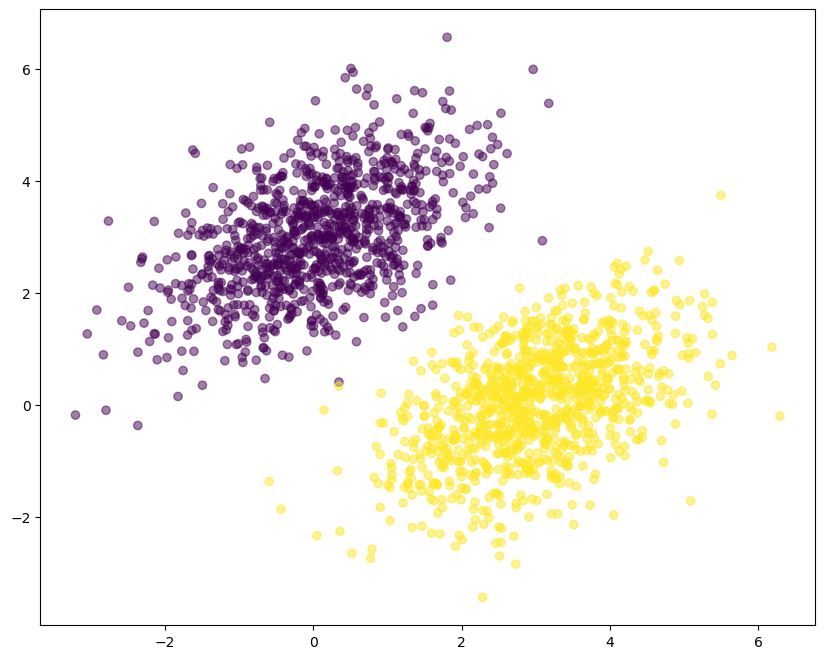

In [26]:
# visualize the two classes, color points based on the target labels
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0], alpha=0.5);

Create a linear classifier using TensorFlow tensors variables.  As we have discussed, a linear classifier simply performs
an affine transformation (a weight sum of the inputs and a shift by bias terms)
`(prediction = W @ input + b)`.
We will train it to minimize the square of the difference between predictions and targets.

Create variables `W` for model parameter weights and `b` for the bias terms, initialzed with random values and with zeros respectively.

In [27]:
# the inputs will be 2D points
input_dim = 2

# the output predicitons will be a single score per sample (close to 0 if the sample is predicted to be class 0, and close
# to 1 if the sample is predicted to be class 1).
output_dim = 1

# create TensorFlow variables of the appropriate shape for this linear classification model
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [28]:
print(W)
print(b)

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[0.2363851],
       [0.7654437]], dtype=float32)>
<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([0.], dtype=float32)>


Compute a forward pass, this function assumes global defined parameter matrix `W` and bias vector `b`.

In [29]:
def model(inputs):
    """Perform a forward pass on a set of inputs using TensorFlow operations.
    This function assume and uses globaly defined weight matrix W and bias vector
    b
    """
    return tf.matmul(inputs, W) + b

The operation ends up berforming a weightd sum and adding in the bias, e.g. `prediction = w1 * x + w2 * y + b`.
`w1` and `w2` represent $\theta_1$ and $\theta_2$ parameters of a linear classifier as we have defined them previously, and
`b` would be $\theta_0$.

Next define a simple mean squared error loss function to use for gradient descent optimization.

In [30]:
def square_loss(predictions, targets):
    """Compute mean squared error.  We are given the targets and predicitons
    as TensorFlow variables.  They are expected to be vectors of the same size, representing
    predictions and target labels for some number of training input samples.
    """
    # per_sample_losses will be a tensor with the same shape as targets and predictions, containing per-sample loss scores
    per_sample_losses = tf.square(targets - predictions)
    
    # we need to sum the per sample losses to a single loss value and take the mean of thes sum of the square losses
    return tf.reduce_mean(per_sample_losses)

Next is a function for performing training steps.  This takes training data and updates the weights `W` and
bias terms `b` so as to reduce the loss on the data.

**NOTE**: This is a neat basic example, notice using the power of the `TensorFlow` tape to create the Computation Graph for the forward pass, and compute the gradients
for the backward pass.  The update, once we calculate the gradients, is simply done by multiplying the gradient by the learning rate, and subtracting this since
we want to go in the opposite direction from the determined gradient.

In [31]:
# gradient descent meta_parameter
learning_rate = 0.1

def training_step(inputs, targets):
    """Perform a single step of training.  Use a TensorFlow gradient tape to
    perform pass, compute loss, and then calculate gradients to perform
    gradient descent.
    """
    # forward pass inside a gradient tape scope
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(predictions, targets)
        
    # calculate gradients with respect to W and b
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    
    # update the weights based on gradients by taking a step in correct direction scaled
    # by the learning rate
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    
    # we return the loss for reporting purposes when performing training steps
    return loss

We do *full batch training* rather than *mini-batch training* for simplicity: e.g. run each training step (gradient
computation and weight update) for all training data.

Full batch training should require fewer training steps, and we should use a larger learning rate than we
typically would use for mini-batches.

In [32]:
# perform 40 full batch epochs of training
for step in range(40):
    loss = training_step(inputs, targets)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 3.5626
Loss at step 1: 0.3919
Loss at step 2: 0.1562
Loss at step 3: 0.1151
Loss at step 4: 0.1030
Loss at step 5: 0.0957
Loss at step 6: 0.0896
Loss at step 7: 0.0841
Loss at step 8: 0.0790
Loss at step 9: 0.0744
Loss at step 10: 0.0702
Loss at step 11: 0.0664
Loss at step 12: 0.0629
Loss at step 13: 0.0597
Loss at step 14: 0.0567
Loss at step 15: 0.0540
Loss at step 16: 0.0516
Loss at step 17: 0.0493
Loss at step 18: 0.0473
Loss at step 19: 0.0454
Loss at step 20: 0.0437
Loss at step 21: 0.0422
Loss at step 22: 0.0407
Loss at step 23: 0.0394
Loss at step 24: 0.0382
Loss at step 25: 0.0371
Loss at step 26: 0.0361
Loss at step 27: 0.0352
Loss at step 28: 0.0344
Loss at step 29: 0.0336
Loss at step 30: 0.0329
Loss at step 31: 0.0323
Loss at step 32: 0.0317
Loss at step 33: 0.0312
Loss at step 34: 0.0307
Loss at step 35: 0.0302
Loss at step 36: 0.0298
Loss at step 37: 0.0295
Loss at step 38: 0.0291
Loss at step 39: 0.0288


There is some randomness, but usually training slows done to below 0.03 after 30 or so epochs.

We will use a threshold of 0.5 to determine if prediction is a 0 or 1. 

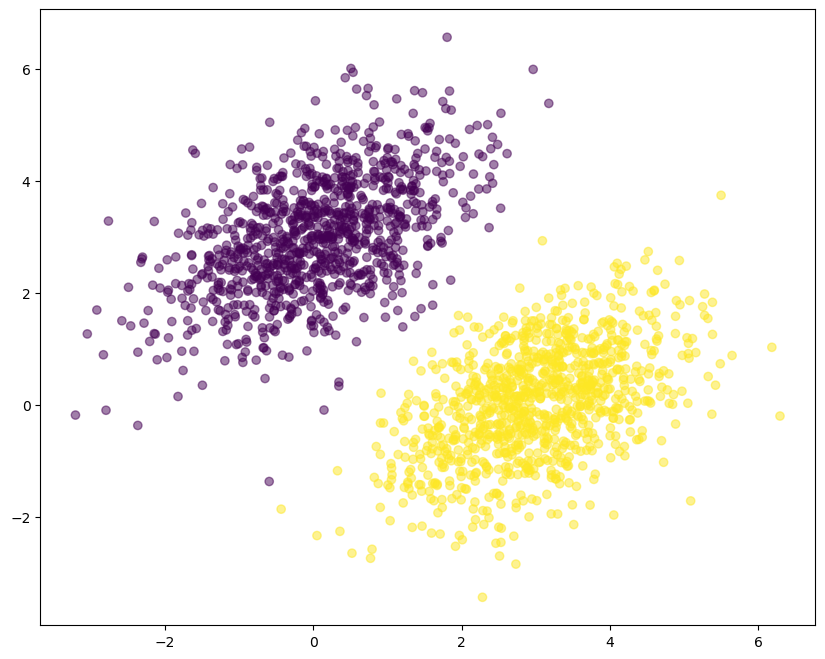

In [33]:
predictions = model(inputs)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5, alpha=0.5);

You may need to examine closely, but some points close to border will be misclassified, though majority will be correctly classified.

Here the trained weight and bias parameters form the equation of a line in the 2D plane.  The decision boundary is made at a value of
0.5.  Thus the decision boundary line has the equation `w1 * x + w2 * y + b = 0.5`.  A little algebra/geometry allows us to plot this line.

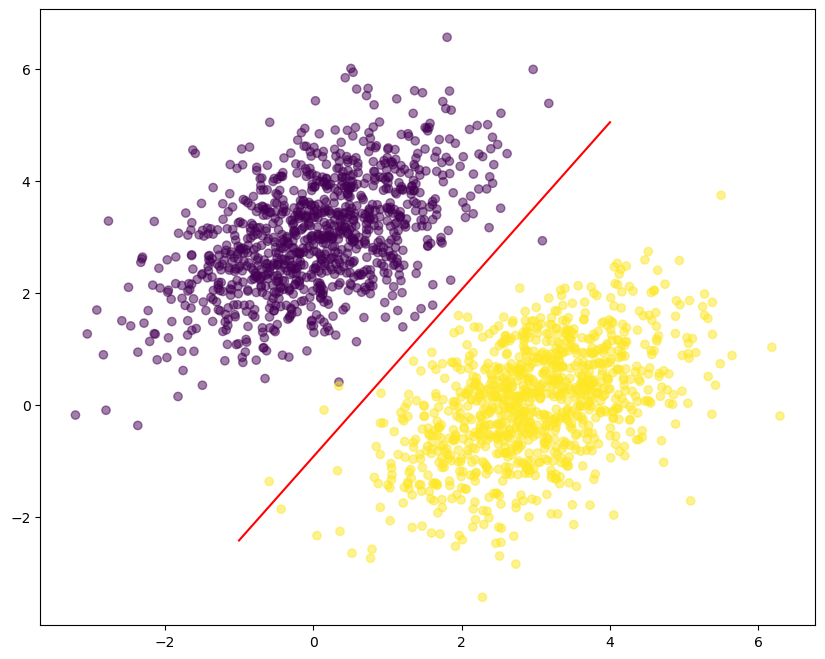

In [34]:
# generate 100 regularly spaced numbers between -1 and 4 which we will use to plot the decision boundary
x = np.linspace(-1, 4, 100)

# this is the equation of our line, plugging in the weight and bias parameters to compute y position
# for the x feature.  This line is the location where predictions change from $< 0.5$ to $> 0.5$
y = (-W[0] / W[1]) * x + (0.5 - b) / W[1]

# plot the decision boundary as a red line
plt.plot(x, y, '-r')

# replot the samples as well, though here I plot using the label for color different from text, to make
# it easier to spot misclassified samples
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0], alpha=0.5);